# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [60]:
df['Pclass'].describe()

count    891.000000
mean       2.308642
std        0.836071
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        3.000000
Name: Pclass, dtype: float64

In [63]:
df.groupby(['Sex', 'Age'])['Survived'].count()

Sex     Age  
female  0.75     2
        1.00     2
        2.00     6
        3.00     2
        4.00     5
                ..
male    70.00    2
        70.50    1
        71.00    2
        74.00    1
        80.00    1
Name: Survived, Length: 145, dtype: int64

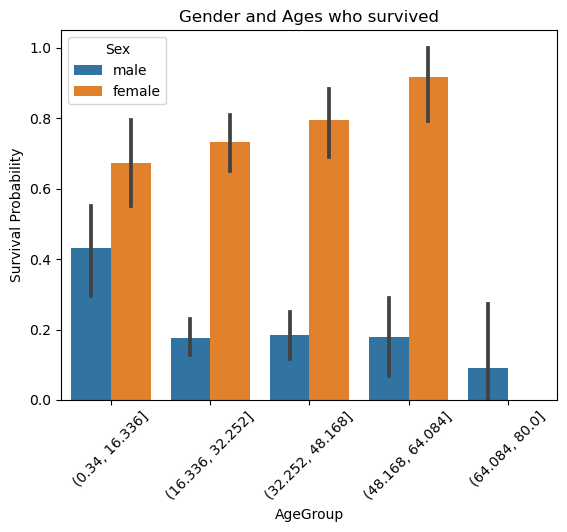

AgeGroup
(0.34, 16.336]      100
(16.336, 32.252]    346
(32.252, 48.168]    188
(48.168, 64.084]     69
(64.084, 80.0]       11
Name: Survived, dtype: int64

In [25]:
likely_alive = df.loc[df['Survived'] == 1]

likely_dead = df.loc[df['Survived'] == 0]

df['AgeGroup'] = pd.cut(df['Age'], bins = 5)

sns.barplot(data = df, x = 'AgeGroup', y = 'Survived', hue = 'Sex')
plt.xticks(rotation = 45)
plt.ylabel("Survival Probability")
plt.title("Gender and Ages who survived")
plt.show()

df.groupby('AgeGroup')['Survived'].count()

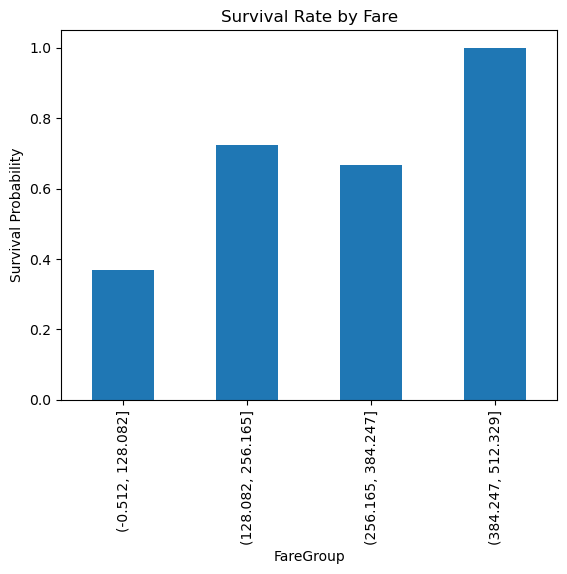

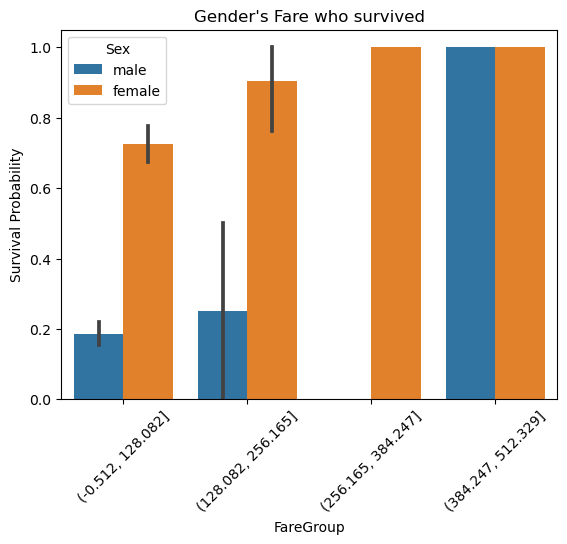

In [96]:
df['FareGroup'] = pd.cut(df['Fare'], bins = 4)
df.groupby('FareGroup')['Survived'].mean().plot(kind='bar')
plt.ylabel('Survival Probability')
plt.title('Survival Rate by Fare')
plt.show()
df.groupby('FareGroup')['Survived'].count()
df.groupby(['Sex','FareGroup'])['Survived'].mean()

sns.barplot(data = df, x = 'FareGroup', y = 'Survived', hue = 'Sex')
plt.xticks(rotation = 45)
plt.ylabel("Survival Probability")
plt.title("Gender's Fare who survived")
plt.show()

In [106]:
df.groupby(['Sex','FareGroup'])['Survived'].count()


Sex     FareGroup         
female  (-0.512, 128.082]     288
        (128.082, 256.165]     21
        (256.165, 384.247]      4
        (384.247, 512.329]      1
male    (-0.512, 128.082]     565
        (128.082, 256.165]      8
        (256.165, 384.247]      2
        (384.247, 512.329]      2
Name: Survived, dtype: int64

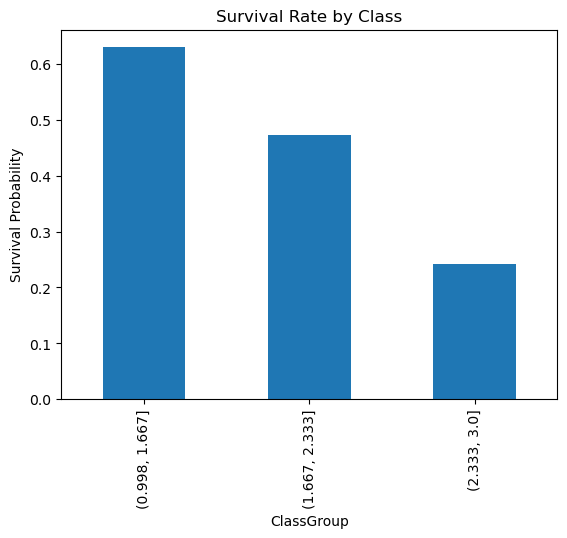

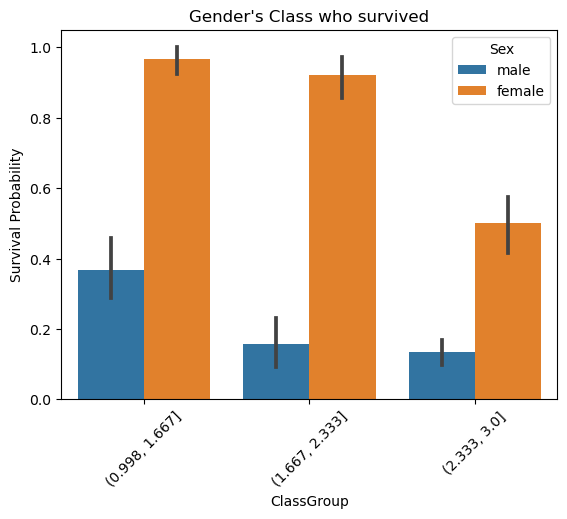

In [104]:
df['ClassGroup'] = pd.cut(df['Pclass'], bins = 3)
df.groupby('ClassGroup')['Survived'].mean().plot(kind='bar')
plt.ylabel('Survival Probability')
plt.title('Survival Rate by Class')
plt.show()


sns.barplot(data = df, x = 'ClassGroup', y = 'Survived', hue = 'Sex')
plt.xticks(rotation = 45)
plt.ylabel("Survival Probability")
plt.title("Gender's Class who survived")
plt.show()

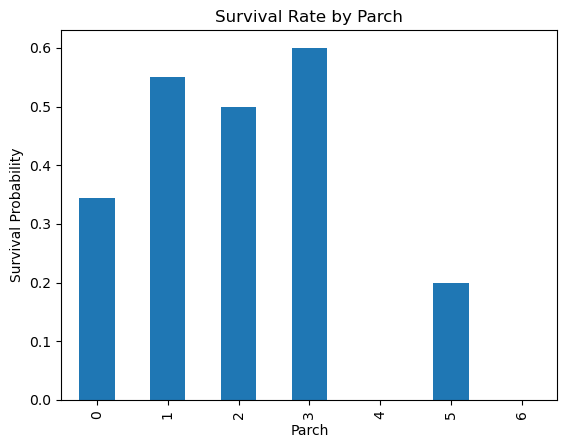

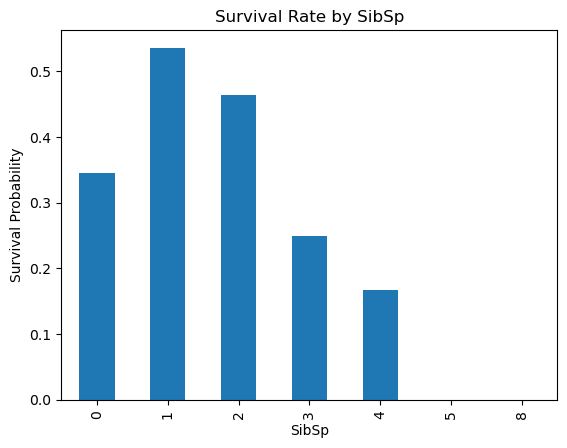

In [17]:
df.groupby('Parch')['Survived'].mean().plot(kind='bar')
plt.ylabel('Survival Probability')
plt.title('Survival Rate by Parch')
plt.show()

df.groupby('SibSp')['Survived'].mean().plot(kind='bar')
plt.ylabel('Survival Probability')
plt.title('Survival Rate by SibSp')
plt.show()

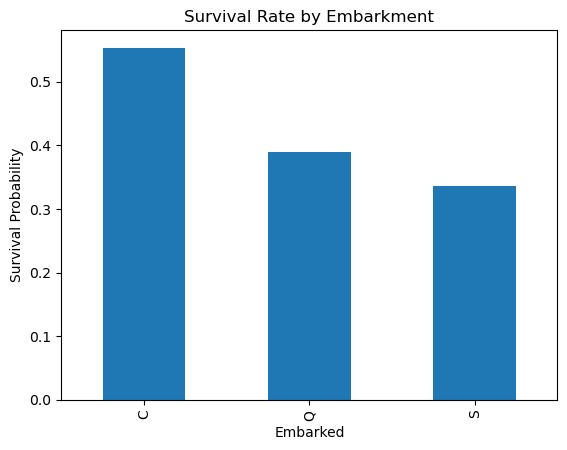

In [18]:
df.groupby('Embarked')['Survived'].mean().plot(kind='bar')
plt.ylabel('Survival Probability')
plt.title('Survival Rate by Embarkment')
plt.show()

In [50]:
condition = ((df['Sex'] == 'female') &
            (df['Age'] >= 18) & 
            (df['Age'] <= 46) &
            (df['Pclass'] == 1) & 
            (df['Parch'] <= 3) & 
            (df['SibSp'] <=3) & 
            (df['Embarked'] == 'C')
           )

list_survived = df.loc[condition]
list_survived

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ParchGroup,AgeGroup
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,"(-0.006, 1.0]","(32.252, 48.168]"
194,195,1,1,"Brown, Mrs. James Joseph (Margaret Tobin)",female,44.0,0,0,PC 17610,27.7208,B4,C,"(-0.006, 1.0]","(32.252, 48.168]"
215,216,1,1,"Newell, Miss. Madeleine",female,31.0,1,0,35273,113.2750,D36,C,"(-0.006, 1.0]","(16.336, 32.252]"
218,219,1,1,"Bazzani, Miss. Albina",female,32.0,0,0,11813,76.2917,D15,C,"(-0.006, 1.0]","(16.336, 32.252]"
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,"(-0.006, 1.0]","(32.252, 48.168]"
291,292,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,B49,C,"(-0.006, 1.0]","(16.336, 32.252]"
309,310,1,1,"Francatelli, Miss. Laura Mabel",female,30.0,0,0,PC 17485,56.9292,E36,C,"(-0.006, 1.0]","(16.336, 32.252]"
310,311,1,1,"Hays, Miss. Margaret Bechstein",female,24.0,0,0,11767,83.1583,C54,C,"(-0.006, 1.0]","(16.336, 32.252]"
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,"(1.0, 2.0]","(16.336, 32.252]"
319,320,1,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.5000,E34,C,"(-0.006, 1.0]","(32.252, 48.168]"


In [61]:
condition_x = ((df['Sex'] == 'male') &
            (df['Age'] >= 18) & 
            (df['Age'] <= 58) &
            (df['Pclass'] == 1) & 
            (df['Parch'] >= 0) & 
            (df['SibSp'] >= 0) & 
            (df['Embarked'] == 'C') &
             (df['Survived'] == 0)
           )

list_perished = df.loc[condition_x]
list_perished

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,ParchGroup,AgeGroup
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C,"(-0.006, 1.0]","(32.252, 48.168]"
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C,"(-0.006, 1.0]","(16.336, 32.252]"
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C,"(-0.006, 1.0]","(16.336, 32.252]"
139,140,0,1,"Giglio, Mr. Victor",male,24.0,0,0,PC 17593,79.2000,B86,C,"(-0.006, 1.0]","(16.336, 32.252]"
155,156,0,1,"Williams, Mr. Charles Duane",male,51.0,0,1,PC 17597,61.3792,NaN,C,"(-0.006, 1.0]","(48.168, 64.084]"
174,175,0,1,"Smith, Mr. James Clinch",male,56.0,0,0,17764,30.6958,A7,C,"(-0.006, 1.0]","(48.168, 64.084]"
273,274,0,1,"Natsch, Mr. Charles H",male,37.0,0,1,PC 17596,29.7000,C118,C,"(-0.006, 1.0]","(32.252, 48.168]"
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,NaN,C,"(-0.006, 1.0]","(16.336, 32.252]"
377,378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C,"(1.0, 2.0]","(16.336, 32.252]"
452,453,0,1,"Foreman, Mr. Benjamin Laventall",male,30.0,0,0,113051,27.7500,C111,C,"(-0.006, 1.0]","(16.336, 32.252]"


In [69]:
df.loc[df['Name'] == 'Bazzani, Miss. Albina', ['Name','Age', 'Fare','Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked']]

,Name,Age,Fare,Sex,Pclass,SibSp,Parch,Embarked
218,"Bazzani, Miss. Albina",32.0,76.2917,female,1,0,0,C


In [ ]:
Miss Albina went on to file a sizeable claim for loss of property ($2890)
and also claimed that the Oceanic Steamship Navigation Company owed her compensation. 

In [70]:
df.loc[df['Name'] == 'Newell, Mr. Arthur Webster', ['Name','Age', 'Fare','Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked']]

,Name,Age,Fare,Sex,Pclass,SibSp,Parch,Embarked
659,"Newell, Mr. Arthur Webster",58.0,113.275,male,1,0,2,C


In [72]:
Mr.Arthur in his final moment got his 2 daughters safely in a lifeboat, 
sadly he stayed behind to help other woman and children.  
"He led them to a lifeboat (exact number uncertain, possibly 6 or 8) and placed them in. 
His last words to Marjorie were, 
"It does seem more dangerous for you to get into that boat than to remain here with me here but we must obey orders." 
Marjorie last saw her father standing back helping other women in the boat.


SyntaxError: unterminated string literal (detected at line 3) (2875304879.py, line 3)